# Folder Management / Directory Path Definitions


In [12]:
N_FEATURES = 150
NUM_SAMPLES = 100000
NUM_CLUSTERS = 300
K_NEIGHBORS = 7  # Hyperparameter for k-NN algorithm


In [13]:
# Import necessary libraries for file navigation and image processing
import os
import cv2  # OpenCV for reading images
import matplotlib.pyplot as plt  # For displaying images
import numpy as np
from sklearn.cluster import KMeans
import joblib  # Library to save models and arrays to disk
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from src.extract_features import read_split


In [14]:
def generate_dense_keypoints(image_shape, step_size=15, scales=[10, 20]):
    keypoints = []
    rows, cols = image_shape
    # Spatial grid
    for y in range(0, rows, step_size):
        for x in range(0, cols, step_size):
            # Scale-space iteration
            for size in scales:
                kp = cv2.KeyPoint(float(x), float(y), float(size))
                keypoints.append(kp)
    return keypoints


Found 1500 TRAINING images.
Found 2985 TEST images.
Classes: ['Bedroom', 'Coast', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']


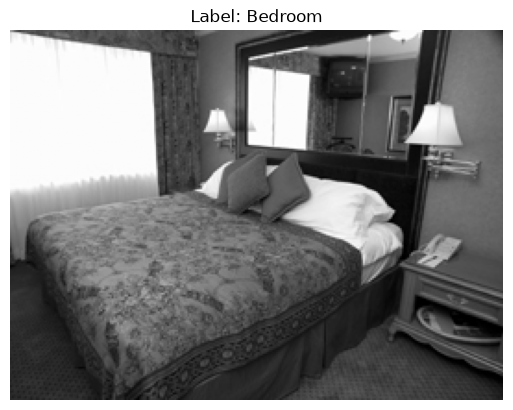

In [15]:
from pathlib import Path

# Dataset folders relative to the project directory
train_path = Path("dataset") / "train"
test_path = Path("dataset") / "test"

# read_split returns: image paths, numeric label indices, class names
train_paths, train_label_ids, classes = read_split(train_path)
test_paths, test_label_ids, classes_test = read_split(test_path)

# Verify that train and test have the same class order
if classes != classes_test:
    raise ValueError(
        f"Train and test classes do not match: {classes} != {classes_test}"
    )

# Use class names as labels throughout the notebook
train_labels = np.array([classes[label_id] for label_id in train_label_ids])
test_labels = np.array([classes[label_id] for label_id in test_label_ids])

print(f"Found {len(train_paths)} TRAINING images.")
print(f"Found {len(test_paths)} TEST images.")
print(f"Classes: {classes}")

# Display the first image to verify path and label
if train_paths:
    first_image = cv2.imread(str(train_paths[0]), cv2.IMREAD_GRAYSCALE)
    if first_image is None:
        raise ValueError(f"Unable to read image: {train_paths[0]}")

    plt.imshow(first_image, cmap="gray")
    plt.title(f"Label: {train_labels[0]}")
    plt.axis("off")
    plt.show()
else:
    print("ERROR: No images found in dataset/train.")


# SIFT Initialization


In [16]:
sift = cv2.SIFT_create(nfeatures=N_FEATURES, contrastThreshold=0.01)

all_keypoints = []
all_descriptors = []
keypoint_counts = []
keypoint_labels = []

for image_path, label in zip(train_paths, train_labels):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Unable to read image: {image_path}")

    # Generate dense keypoints on the grid and compute descriptors
    dense_keypoints = generate_dense_keypoints(image.shape, step_size=15, scales=[10, 20])
    keypoints, descriptors = sift.compute(image, dense_keypoints)
    
    keypoint_counts.append(len(keypoints))
    keypoint_labels.append(label)

    if descriptors is not None:
        all_descriptors.append(descriptors)
        all_keypoints.append(keypoints)

keypoint_counts = np.array(keypoint_counts, dtype=np.int32)
keypoint_labels = np.array(keypoint_labels)

print(f"Images analyzed: {len(keypoint_counts)}")
print(f"Total keypoints: {keypoint_counts.sum()}")


Images analyzed: 1500
Total keypoints: 955426


In [17]:
# 1. Stack all descriptor arrays vertically into a single large matrix
stacked_descriptors = np.vstack(all_descriptors)

total_descriptors = stacked_descriptors.shape[0]
print(f"Total descriptors extracted: {total_descriptors}")

# 2. Set the target number of samples
num_samples = NUM_SAMPLES

# 3. Perform random sampling
if total_descriptors > num_samples:
    print(f"Randomly sampling {num_samples} descriptors...")

    # Generate random row indices without replacement
    random_indices = np.random.choice(total_descriptors, num_samples, replace=False)

    # Filter the original matrix using random indices
    sampled_descriptors = stacked_descriptors[random_indices, :]
else:
    print("Under the maximum limit, keeping all descriptors.")
    sampled_descriptors = stacked_descriptors

# Final check
print(f"Ready for K-Means! Final array shape: {sampled_descriptors.shape}")


Total descriptors extracted: 955426
Randomly sampling 100000 descriptors...
Ready for K-Means! Final array shape: (100000, 128)


In [18]:
# 1. Define the number of clusters (visual words)
num_clusters = NUM_CLUSTERS

print(f"Starting K-Means training with k={num_clusters} (this may take a few minutes)...")
start_time = time.time()

# 2. Initialize the K-Means algorithm
# random_state=42 ensures reproducibility
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

# 3. Train the model on sampled descriptors
kmeans.fit(sampled_descriptors)

end_time = time.time()
print(f"K-Means completed in {(end_time - start_time) / 60:.2f} minutes.")

# 4. Extract cluster centroids (the visual vocabulary)
visual_vocabulary = kmeans.cluster_centers_
print(f"Visual vocabulary shape: {visual_vocabulary.shape}")


Starting K-Means training with k=300 (this may take a few minutes)...
K-Means completed in 3.01 minutes.
Visual vocabulary shape: (300, 128)


In [19]:
def compute_spatial_pyramid_L2(image, sift, kmeans, num_clusters):
    h, w = image.shape

    # 1. Dense SIFT extraction
    dense_kp = generate_dense_keypoints((h, w), step_size=15, scales=[10, 20])
    kp, des = sift.compute(image, dense_kp)

    # Final dimension: 1 (L0) + 4 (L1) + 16 (L2) = 21 histograms in total
    total_bins = num_clusters * 21

    if des is None:
        return np.zeros(total_bins)

    # Quantization: assign each descriptor to the closest visual word
    words = kmeans.predict(des)

    # Initialize histogram arrays for the 3 levels
    hist_L0 = np.zeros(num_clusters)            # Level 0: 1 cell (1x1)
    hist_L1 = np.zeros((4, num_clusters))       # Level 1: 4 cells (2x2)
    hist_L2 = np.zeros((16, num_clusters))      # Level 2: 16 cells (4x4)

    # 2. Binning into quadrants/cells
    for keypoint, word in zip(kp, words):
        x, y = keypoint.pt

        # --- Level 0 (Global) ---
        hist_L0[word] += 1

        # --- Level 1 (2x2 Grid) ---
        col_L1 = int((x / w) * 2)
        row_L1 = int((y / h) * 2)
        col_L1 = min(col_L1, 1)
        row_L1 = min(row_L1, 1)
        idx_L1 = row_L1 * 2 + col_L1
        hist_L1[idx_L1, word] += 1

        # --- Level 2 (4x4 Grid) ---
        col_L2 = int((x / w) * 4)
        row_L2 = int((y / h) * 4)
        col_L2 = min(col_L2, 3)
        row_L2 = min(row_L2, 3)
        idx_L2 = row_L2 * 4 + col_L2
        hist_L2[idx_L2, word] += 1

    # 3. Standard Spatial Pyramid Matching (SPM) Weighting
    # Standard weights: L0 = 0.25, L1 = 0.25, L2 = 0.5
    hist_L0 = hist_L0 * 0.25
    hist_L1 = hist_L1 * 0.25
    hist_L2 = hist_L2 * 0.5

    # 4. Concatenation
    hists_to_stack = [hist_L0] + [hist_L1[i] for i in range(4)] + [hist_L2[i] for i in range(16)]
    final_hist = np.concatenate(hists_to_stack)

    # 5. Final normalization
    norm = np.linalg.norm(final_hist)
    if norm > 0:
        final_hist = final_hist / norm

    return final_hist

# --- APPLY TO ENTIRE TRAINING SET ---
print("Generating histograms for the training set...")

X_train = []
y_train = []

for path, label in zip(train_paths, train_labels):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    hist = compute_spatial_pyramid_L2(image, sift, kmeans, num_clusters)
    if hist is not None:
        X_train.append(hist)
        y_train.append(label)

# Convert to NumPy arrays ready for Machine Learning
X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"Done! X_train matrix created with shape: {X_train.shape}")
print(f"y_train label array created with shape: {y_train.shape}")


Generating histograms for the training set...
Done! X_train matrix created with shape: (1500, 6300)
y_train label array created with shape: (1500,)


In [20]:
print("Generating histograms for the TEST set...")

X_test = []
y_test = []

for path, label in zip(test_paths, test_labels):
    # Use the same SIFT and vocabulary (kmeans) trained on the training set!
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    hist = compute_spatial_pyramid_L2(image, sift, kmeans, num_clusters)
    if hist is not None:
        X_test.append(hist)
        y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Done! X_test matrix created with shape: {X_test.shape}")


Generating histograms for the TEST set...
Done! X_test matrix created with shape: (2985, 6300)


Training Nearest Neighbor classifier...
Computing predictions on the test set...

--- NEAREST NEIGHBOR (7-NN) ACCURACY: 58.66% ---


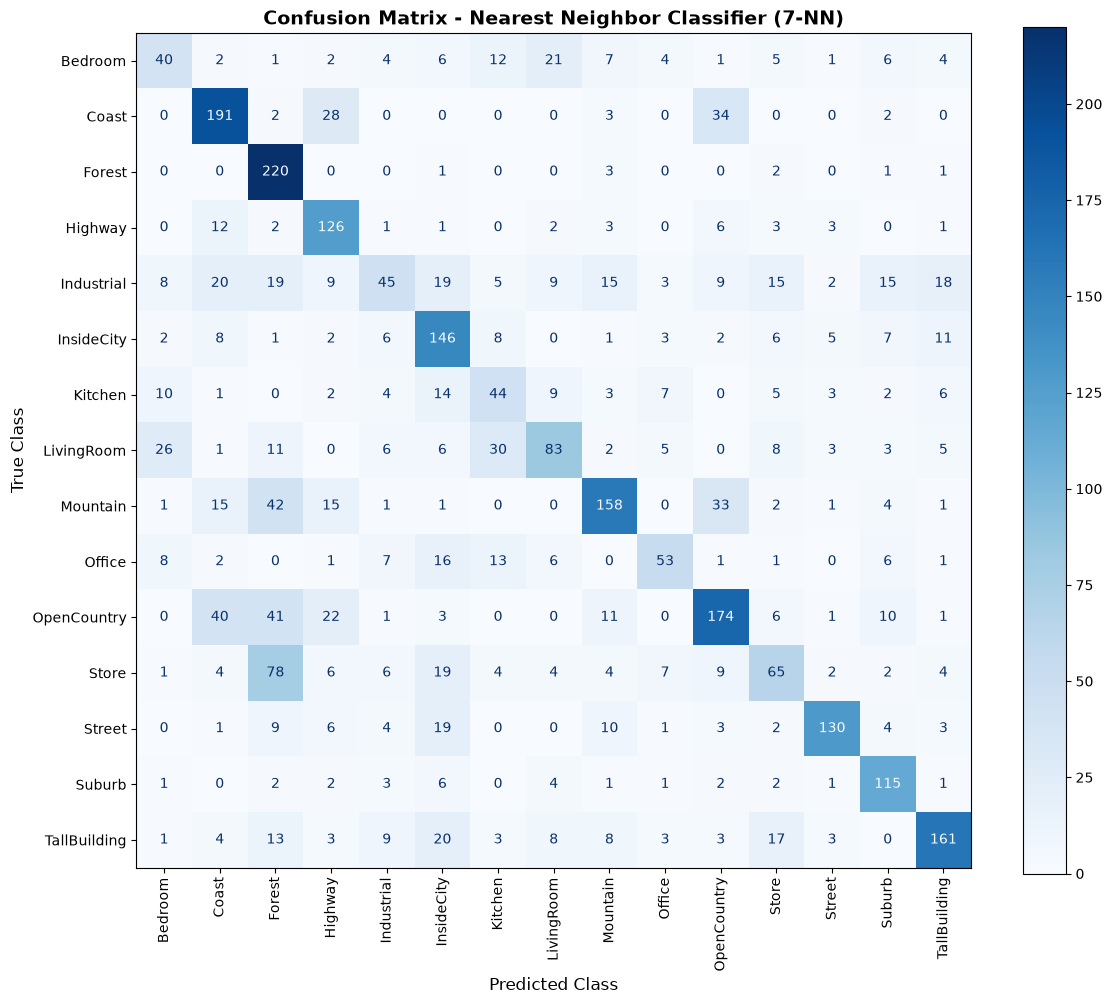

In [21]:
# 1. Initialize K-Nearest Neighbors (k-NN) classifier
# Using the K_NEIGHBORS hyperparameter set at the beginning of the notebook
nn_classifier = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, metric='euclidean')

# 2. Training
print("Training Nearest Neighbor classifier...")
nn_classifier.fit(X_train, y_train)

# 3. Predict on the test set
print("Computing predictions on the test set...")
y_pred_nn = nn_classifier.predict(X_test)

# Compute overall accuracy
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"\n--- NEAREST NEIGHBOR ({K_NEIGHBORS}-NN) ACCURACY: {accuracy_nn * 100:.2f}% ---")

# 4. Confusion Matrix creation
cm_nn = confusion_matrix(y_test, y_pred_nn, labels=classes)

# 5. Confusion Matrix visualization
fig, ax = plt.subplots(figsize=(12, 10))
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=classes)

disp_nn.plot(ax=ax, cmap='Blues', xticks_rotation='vertical', values_format='d')

plt.title(f"Confusion Matrix - Nearest Neighbor Classifier ({K_NEIGHBORS}-NN)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.tight_layout()
plt.show()



--- LINEAR SVM TRAINING AND EVALUATION (One-vs-Rest) ---
Training Linear SVM...
SVM trained in 4.25 seconds.
Computing real-valued decision scores...

--- SVM ACCURACY: 73.37% ---


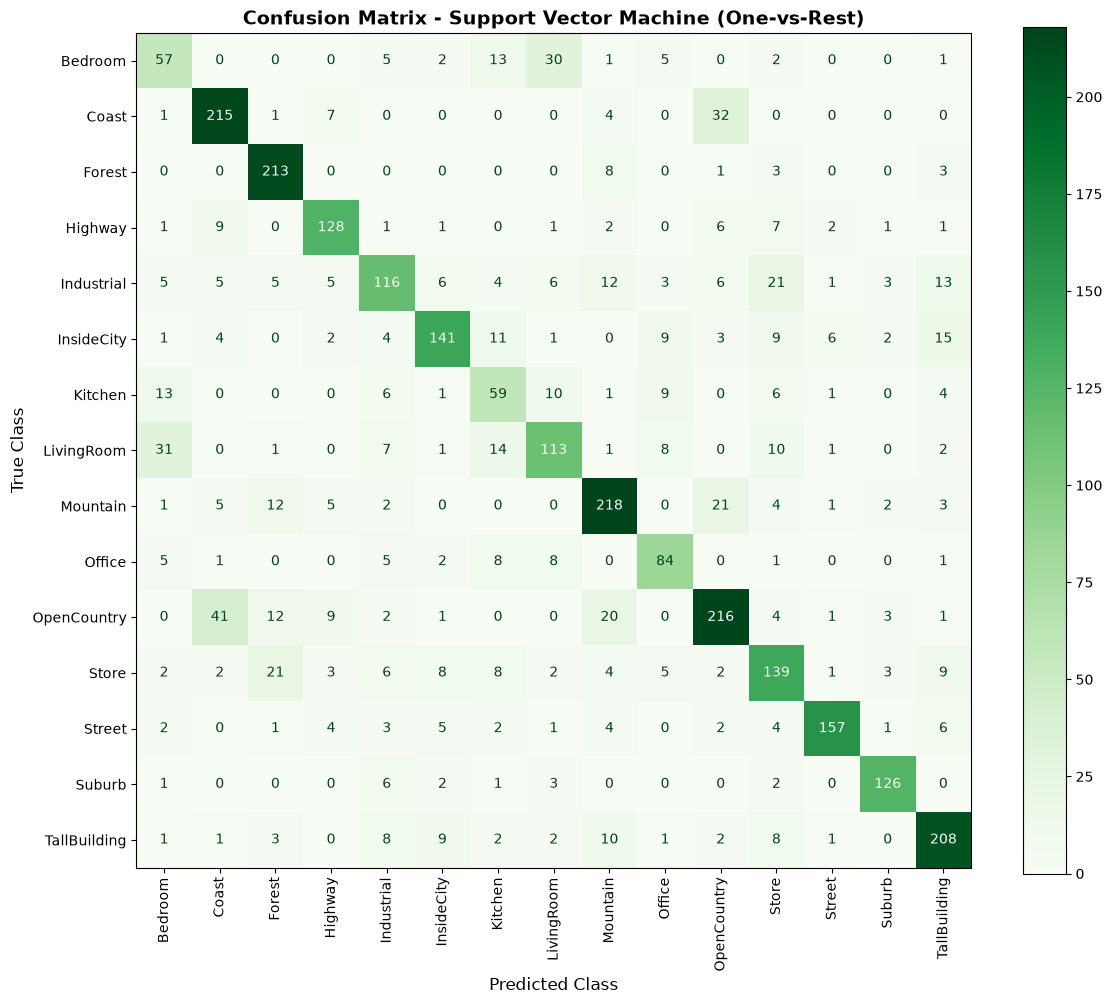

In [22]:
from sklearn.svm import SVC

print("\n--- LINEAR SVM TRAINING AND EVALUATION (One-vs-Rest) ---")

# --- Train multiclass Linear SVM (One-vs-Rest) ---
svm_classifier = SVC(kernel='linear', decision_function_shape='ovr', random_state=42)

print("Training Linear SVM...")
start_time_svm = time.time()
svm_classifier.fit(X_train, y_train)
print(f"SVM trained in {(time.time() - start_time_svm):.2f} seconds.")

# --- Evaluate multiclass SVM ---
print("Computing real-valued decision scores...")

# Compute decision function scores
decision_scores = svm_classifier.decision_function(X_test)

# Assign class corresponding to the maximum decision score
predicted_indices = np.argmax(decision_scores, axis=1)

y_pred_svm = svm_classifier.classes_[predicted_indices]

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\n--- SVM ACCURACY: {accuracy_svm * 100:.2f}% ---")

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=classes)

# --- CONFUSION MATRIX VISUALIZATION ---
fig, ax = plt.subplots(figsize=(12, 10))
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=classes)

disp_svm.plot(ax=ax, cmap='Greens', xticks_rotation='vertical', values_format='d')

plt.title("Confusion Matrix - Support Vector Machine (One-vs-Rest)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.tight_layout()
plt.show()


Training SVM with Gaussian Kernel (RBF)...
Training complete!
Evaluating on test set...
Gaussian SVM Accuracy: 72.60%


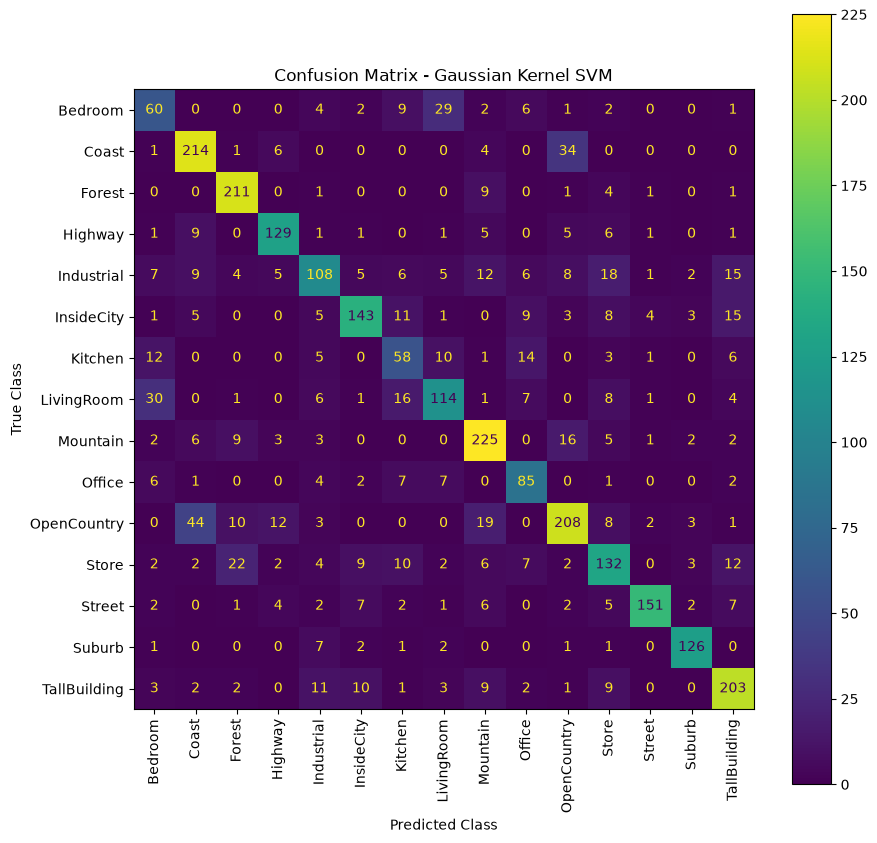

In [23]:
# --- SVM TRAINING WITH GAUSSIAN KERNEL (RBF) ---
print("Training SVM with Gaussian Kernel (RBF)...")

svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

svm_rbf.fit(X_train, y_train)

print("Training complete!")

# --- EVALUATION ON TEST SET ---
print("Evaluating on test set...")
y_pred_rbf = svm_rbf.predict(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Gaussian SVM Accuracy: {acc_rbf * 100:.2f}%")

cm_rbf = confusion_matrix(y_test, y_pred_rbf, labels=classes)
disp_rbf = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=classes)

fig, ax = plt.subplots(figsize=(10, 10))
disp_rbf.plot(ax=ax, xticks_rotation='vertical')
plt.title("Confusion Matrix - Gaussian Kernel SVM")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()


Configuring ECOC classifier with Gaussian SVM (RBF)...
Starting ECOC model training...
Training completed successfully!
Computing predictions on test set...
Overall ECOC-SVM Model Accuracy: 63.32%
Generating confusion matrix...


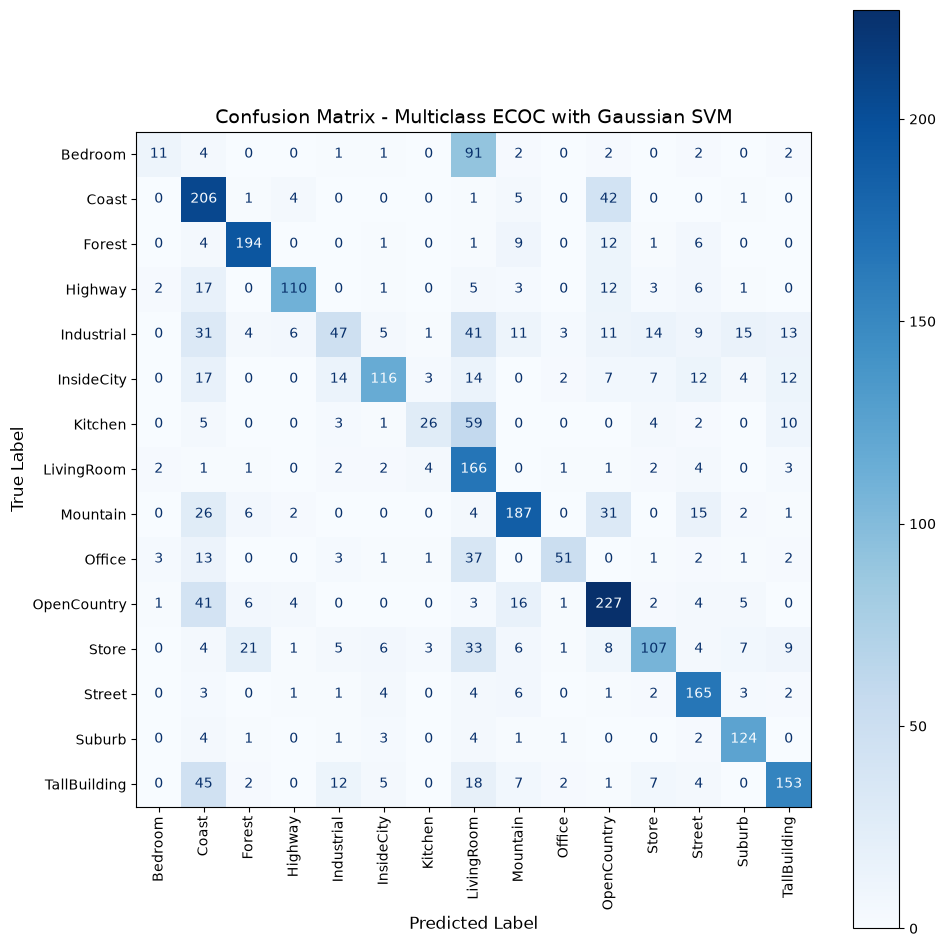

In [24]:
from sklearn.multiclass import OutputCodeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# --- 1. ECOC + GAUSSIAN SVM MODEL CONFIGURATION ---
print("Configuring ECOC classifier with Gaussian SVM (RBF)...")

base_svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

ecoc_pipeline = make_pipeline(
    StandardScaler(),
    OutputCodeClassifier(estimator=base_svm, code_size=1.5, random_state=42),
)

# --- 2. TRAINING ---
print("Starting ECOC model training...")
ecoc_pipeline.fit(X_train, y_train)
print("Training completed successfully!")

# --- 3. PREDICTIONS ON TEST SET ---
print("Computing predictions on test set...")
y_pred_ecoc = ecoc_pipeline.predict(X_test)

# --- 4. EVALUATION AND ACCURACY ---
acc_ecoc = accuracy_score(y_test, y_pred_ecoc)
print(f"Overall ECOC-SVM Model Accuracy: {acc_ecoc * 100:.2f}%")

# --- 5. CONFUSION MATRIX COMPUTATION AND DISPLAY ---
print("Generating confusion matrix...")
cm_ecoc = confusion_matrix(y_test, y_pred_ecoc, labels=classes)

fig, ax = plt.subplots(figsize=(10, 10))
disp_ecoc = ConfusionMatrixDisplay(confusion_matrix=cm_ecoc, display_labels=classes)
disp_ecoc.plot(ax=ax, xticks_rotation="vertical", cmap=plt.cm.Blues)

plt.title("Confusion Matrix - Multiclass ECOC with Gaussian SVM", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()
